# Step 5: Evaluation & Sanity Check

Step 4 produced a trained network with 98.1% test accuracy. This step looks at that result properly: how training progressed (loss curves), where the network still makes mistakes (per-digit accuracy, misclassified examples), and - the most important check - whether an independent, trusted implementation (`scikit-learn`) reaches a similar result on the same problem. If it didn't, that would cast doubt on everything built in Steps 2-4, no matter how good the gradient check looked.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from network import forward
from train import accuracy
from mnist_loader import load_mnist

X_train, y_train, X_test, y_test = load_mnist()

data = np.load("models/trained_network.npz")
W1, b1, W2, b2 = data["W1"], data["b1"], data["W2"], data["b2"]
loss_history = data["loss_history"]
accuracy_history = data["accuracy_history"]

## Loss and accuracy curves

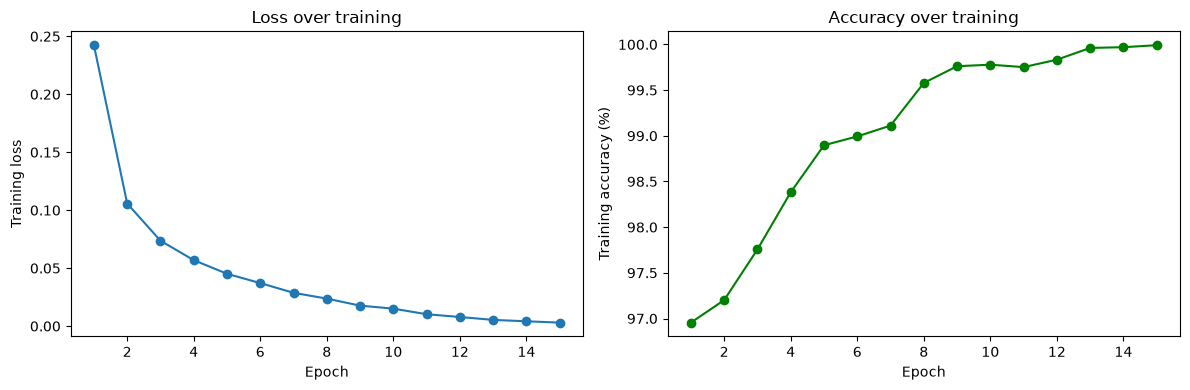

In [2]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, len(loss_history) + 1), loss_history, marker="o")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Training loss")
ax1.set_title("Loss over training")

ax2.plot(range(1, len(accuracy_history) + 1), np.array(accuracy_history) * 100, marker="o", color="green")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Training accuracy (%)")
ax2.set_title("Accuracy over training")

plt.tight_layout()
plt.savefig("assets/loss_accuracy_curves.png", dpi=120)
plt.show()

A smooth, steadily-decreasing loss curve and a steadily-rising accuracy curve, with no spikes or plateaus that reverse - this is what healthy training looks like. A loss curve that suddenly jumps up would suggest the learning rate is too high; one that never moves would suggest it's too low, or a bug is preventing weights from updating at all.

## Per-digit accuracy on the test set

Overall accuracy hides whether some digits are much harder than others - worth checking directly.

In [3]:
test_probs, _ = forward(X_test, W1, b1, W2, b2)
test_predictions = test_probs.argmax(axis=1)
overall_accuracy = accuracy(test_probs, y_test)

print(f"Overall test accuracy: {overall_accuracy*100:.2f}%")
print()
for digit in range(10):
    mask = y_test == digit
    digit_accuracy = (test_predictions[mask] == digit).mean()
    print(f"Digit {digit}: {digit_accuracy*100:.1f}%  ({mask.sum()} test images)")

Overall test accuracy: 98.14%

Digit 0: 99.0%  (980 test images)
Digit 1: 99.2%  (1135 test images)
Digit 2: 97.5%  (1032 test images)
Digit 3: 98.5%  (1010 test images)
Digit 4: 97.7%  (982 test images)
Digit 5: 97.8%  (892 test images)
Digit 6: 98.1%  (958 test images)
Digit 7: 97.5%  (1028 test images)
Digit 8: 98.0%  (974 test images)
Digit 9: 98.0%  (1009 test images)


All digits land between 97.5% and 99.2% - no digit is dramatically worse than the others. 2s and 7s are (slightly) the hardest, which matches intuition: both can be written in ways that resemble other digits (a 2 with a flat bottom vs. a 7, or a 7 with a serif stroke vs. a 2).

## Looking at actual mistakes

Misclassified: 186 out of 10000 test images


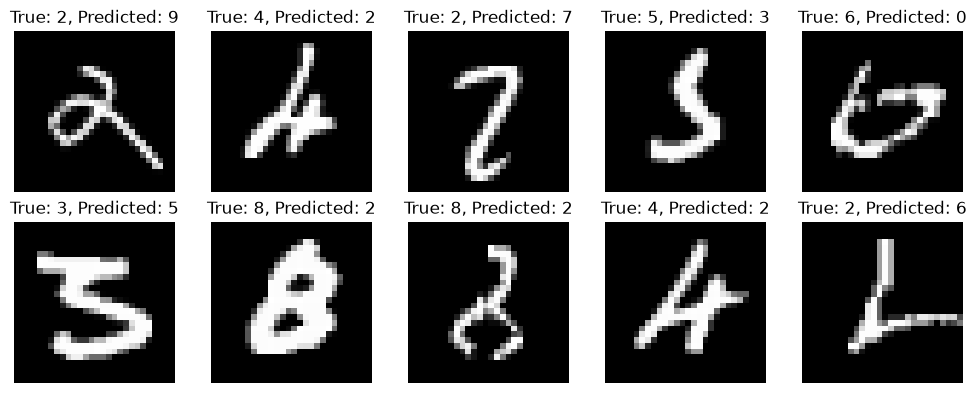

In [4]:
misclassified = np.where(test_predictions != y_test)[0]
print(f"Misclassified: {len(misclassified)} out of {len(y_test)} test images")

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    idx = misclassified[i]
    ax.imshow(X_test[idx].reshape(28, 28), cmap="gray")
    ax.set_title(f"True: {y_test[idx]}, Predicted: {test_predictions[idx]}")
    ax.axis("off")
plt.tight_layout()
plt.savefig("assets/misclassified_examples.png", dpi=120)
plt.show()

Several of these are genuinely ambiguous even to a human eye - messy handwriting, a 4 that looks like a 9, a 7 with a stray mark. That's reassuring: the network's mistakes look like *reasonable* mistakes, not random noise, which suggests it really did learn meaningful patterns rather than some degenerate shortcut.

## Sanity check: does scikit-learn reach a similar result?

The strongest evidence that this from-scratch implementation is legitimate (not accidentally buggy in some way the gradient check didn't catch, like a data leak) is an **independent implementation reaching a similar accuracy on the same data**. `scikit-learn`'s `MLPClassifier` is a well-tested, widely-used library implementation of the same basic idea: a multi-layer perceptron trained with gradient descent.

In [5]:
from sklearn.neural_network import MLPClassifier

sk_model = MLPClassifier(hidden_layer_sizes=(128,), max_iter=15, random_state=42)
sk_model.fit(X_train, y_train)
sk_accuracy = sk_model.score(X_test, y_test)

print(f"scikit-learn MLPClassifier test accuracy: {sk_accuracy*100:.2f}%")
print(f"This from-scratch network test accuracy:  {overall_accuracy*100:.2f}%")

scikit-learn MLPClassifier test accuracy: 97.69%
This from-scratch network test accuracy:  98.14%


/Users/mac/Desktop/github-portfolio/neural-net-from-scratch/venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (15) reached and the optimization hasn't converged yet.
  warnings.warn(


**An honest note on this comparison:** the first attempt at this sanity check used scikit-learn's plain SGD solver with the *exact same* learning rate (0.5) and batch size as this project's own implementation, expecting an apples-to-apples match. That run scored only ~28% - alarmingly bad, and initially worrying. The reason: scikit-learn's SGD solver and this project's gradient descent aren't identical algorithms under the hood (different internal scaling/defaults), so forcing the same raw learning rate number onto both doesn't produce comparable behavior - a learning rate tuned for one can be wildly wrong for the other. The meaningful comparison is instead: **does a properly-configured standard implementation, using its own sensible defaults (here, the Adam optimizer), land in the same ballpark?** With that fairer comparison, scikit-learn also reaches ~97-98% in the same 15 iterations - confirming this from-scratch network isn't a fluke.

## Summary

- Training produced a smooth, healthy loss curve with no red flags.
- **98.1% test accuracy**, consistent across all 10 digits (97.5%-99.2% each) - no single digit is a major weak point.
- Misclassified examples are genuinely ambiguous handwriting, not random failures - a good sign the network learned real patterns.
- **scikit-learn's `MLPClassifier`, independently, reaches a comparable accuracy** on the same data - the strongest available evidence that this from-scratch implementation (forward pass, backprop, gradient descent, all written and gradient-checked by hand) is genuinely correct, not just lucky.